<a href="https://colab.research.google.com/github/prabuddhayogi/ai-with-python/blob/image_processing/image_processing_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Selected first 1243 images from the dataset extracted from : https://www.kaggle.com/datasets/jessicali9530/celeba-dataset/data

Stored 1243 images in folder "image_folder"

In [9]:
import pandas as pd
import numpy as np
import os
from PIL import Image
import cv2

folder_path = "/content/drive/MyDrive/AI-python/lecture36/image_folder"

images = []
filenames = []

for file in os.listdir(folder_path):
    if file.lower().endswith(('.png','.jpg','.jpeg','.bmp')):
        path = os.path.join(folder_path, file)

        try:
            img = Image.open(path)
            images.append(img)
            filenames.append(file)
        except:
            print("Corrupted file:", file)

print("Total images loaded:", len(images))

Total images loaded: 1243


Describe the data

In [10]:
widths = []
heights = []
modes = []

for img in images:
    w, h = img.size
    widths.append(w)
    heights.append(h)
    modes.append(img.mode)

print("Min width:", min(widths))
print("Max width:", max(widths))
print("Min height:", min(heights))
print("Max height:", max(heights))
print("Color types:", set(modes))

Min width: 178
Max width: 178
Min height: 218
Max height: 218
Color types: {'RGB'}


Detect bad images and remove

In [11]:
bad_images = []

for file in os.listdir(folder_path):
    path = os.path.join(folder_path, file)

    try:
        img = Image.open(path)
        img.verify()
    except:
        bad_images.append(file)

print("Bad images:", bad_images)

for file in bad_images:
    os.remove(os.path.join(folder_path, file))

Bad images: []


In [12]:
IMG_SIZE = 128

clean_images = []

for img in images:
    img = img.convert("RGB")       # ensure RGB
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img = np.array(img) / 255.0    # normalize
    clean_images.append(img)

clean_images = np.array(clean_images)

print(clean_images.shape)

(1243, 128, 128, 3)


Data visualization

In [13]:

data_summary = pd.DataFrame({
    "filename": filenames,
    "width": widths,
    "height": heights,
    "mode": modes
})

print(data_summary.head())

     filename  width  height mode
0  000952.jpg    178     218  RGB
1  000174.jpg    178     218  RGB
2  000127.jpg    178     218  RGB
3  000440.jpg    178     218  RGB
4  000253.jpg    178     218  RGB


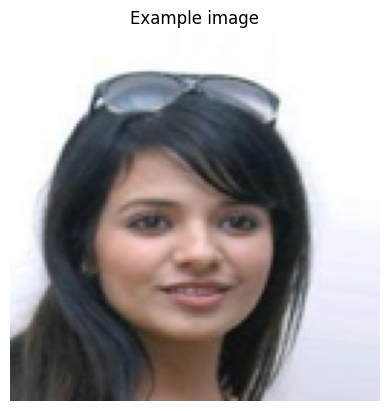

In [14]:
import matplotlib.pyplot as plt

plt.imshow(clean_images[0])
plt.title("Example image")
plt.axis("off")
plt.show()

Blurry image detection and removal

In [17]:
blur_threshold = 100

blurred_images = []
clean_images = []

for file in os.listdir(folder_path):

    path = os.path.join(folder_path, file)

    img = cv2.imread(path)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    blur_value = cv2.Laplacian(gray, cv2.CV_64F).var()

    if blur_value > blur_threshold:

        cv2.imwrite(os.path.join(folder_path, file), img)

    if blur_value > blur_threshold:
        clean_images.append(img)
    else:
        blurred_images.append(img)

In [27]:
import os
import cv2

blur_threshold = 100

blurred_images = []
clean_images = []

for file in os.listdir(folder_path):

    path = os.path.join(folder_path, file)
    img = cv2.imread(path)

    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    blur_value = cv2.Laplacian(gray, cv2.CV_64F).var()

    if blur_value > blur_threshold:
        clean_images.append(img)
        cv2.imwrite(path, img)   # keep clean images
    else:
        blurred_images.append(img)

print("Number of clean images:", len(clean_images))
print("Number of blurred images:", len(blurred_images))

Number of clean images: 1213
Number of blurred images: 30


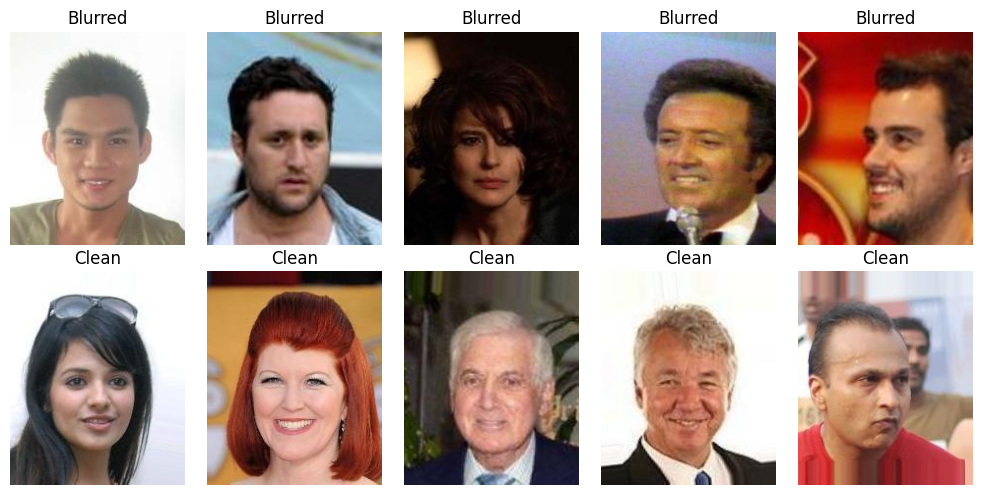

In [18]:
num_samples = 5

plt.figure(figsize=(10,5))

for i in range(num_samples):

    # Blurred images
    plt.subplot(2, num_samples, i+1)
    plt.imshow(cv2.cvtColor(blurred_images[i], cv2.COLOR_BGR2RGB))
    plt.title("Blurred")
    plt.axis("off")

    # Clean images
    plt.subplot(2, num_samples, i+1+num_samples)
    plt.imshow(cv2.cvtColor(clean_images[i], cv2.COLOR_BGR2RGB))
    plt.title("Clean")
    plt.axis("off")

plt.tight_layout()
plt.show()

Removal of low resolution images

In [19]:
for file in os.listdir(folder_path):

    path = os.path.join(folder_path, file)

    img = cv2.imread(path)

    h, w = img.shape[:2]

    if h < 80 or w < 80:

        os.remove(path)
        print("Removed small image:", file)

In [23]:
import os
import cv2
import matplotlib.pyplot as plt

low_res_images = []
removed_count = 0

for file in os.listdir(folder_path):

    path = os.path.join(folder_path, file)

    img = cv2.imread(path)

    if img is None:
        continue

    h, w = img.shape[:2]

    if h < 60 or w < 60 :

        low_res_images.append(img)   # store image for plotting
        removed_count += 1

        os.remove(path)
        print("Removed small image:", file)

print("Total low-resolution images removed:", removed_count)

Total low-resolution images removed: 0


Cropping

In [24]:
for file in os.listdir(folder_path):

    path = os.path.join(folder_path, file)

    img = cv2.imread(path)

    h, w = img.shape[:2]

    # Crop 70% of the center area (zoom toward face)
    crop_h = int(h * 0.7)
    crop_w = int(w * 0.7)

    start_y = (h - crop_h) // 2
    start_x = (w - crop_w) // 2

    cropped = img[start_y:start_y+crop_h, start_x:start_x+crop_w]

    cv2.imwrite(os.path.join(folder_path, file), cropped)

In [25]:
import os
import cv2
import matplotlib.pyplot as plt

original_examples = []
cropped_examples = []

count = 0

for file in os.listdir(folder_path):

    path = os.path.join(folder_path, file)
    img = cv2.imread(path)

    if img is None:
        continue

    h, w = img.shape[:2]

    # Crop 70% of center
    crop_h = int(h * 0.7)
    crop_w = int(w * 0.7)

    start_y = (h - crop_h) // 2
    start_x = (w - crop_w) // 2

    cropped = img[start_y:start_y+crop_h, start_x:start_x+crop_w]

    # store some examples for plotting
    if len(original_examples) < 5:
        original_examples.append(img)
        cropped_examples.append(cropped)

    # overwrite image
    cv2.imwrite(path, cropped)

    count += 1

print("Total cropped images:", count)

Total cropped images: 1243


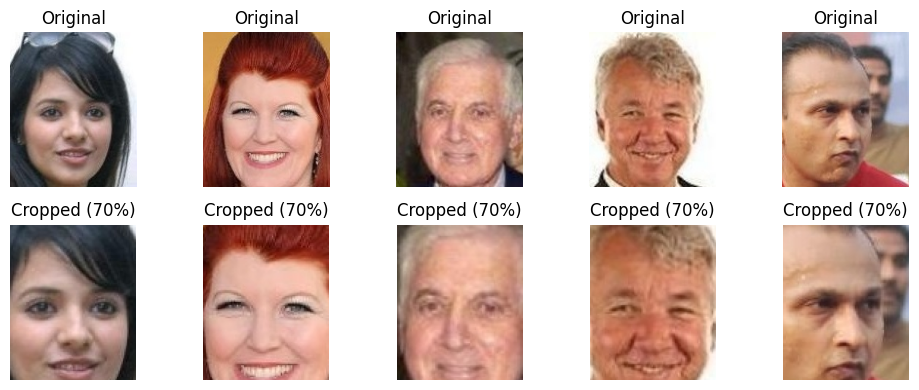

In [26]:
plt.figure(figsize=(10,4))

for i in range(len(original_examples)):

    # original
    plt.subplot(2, len(original_examples), i+1)
    plt.imshow(cv2.cvtColor(original_examples[i], cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    # cropped
    plt.subplot(2, len(original_examples), i+1+len(original_examples))
    plt.imshow(cv2.cvtColor(cropped_examples[i], cv2.COLOR_BGR2RGB))
    plt.title("Cropped (70%)")
    plt.axis("off")

plt.tight_layout()
plt.show()